In [2]:
import pandas as pd
df=pd.read_csv("RFM_DATA.CSV")
df.head()

,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,337,1,114.739998
1,000161a058600d5901f007fab4c27140,458,1,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,596,1,195.419998
3,0002414f95344307404f0ace7a26f1d5,427,1,179.350006
4,000379cdec625522490c315e70c7a9fb,198,1,107.010002


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99440 entries, 0 to 99439
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  99440 non-null  object 
 1   recency      99440 non-null  int64  
 2   frequency    99440 non-null  int64  
 3   monetary     99440 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.0+ MB


,recency,frequency,monetary
count,99440.000000,99440.0,99440.000000
mean,290.268212,1.0,160.990267
std,153.664106,0.0,221.951257
min,0.000000,1.0,0.000000
25%,166.000000,1.0,62.009998
50%,272.000000,1.0,105.290001
75%,400.000000,1.0,176.970001
max,773.000000,1.0,13664.080078


In [4]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaled_data=scaler.fit_transform(df[['recency','frequency','monetary']])


In [7]:
from sklearn.cluster import KMeans
KMeans=KMeans(n_clusters=4,random_state=42)
df['cluster']=KMeans.fit_predict(scaled_data)

In [8]:
df.groupby('cluster')[['recency','frequency','monetary']].mean()

,recency,frequency,monetary
cluster,,,
0,136.151279,1.0,137.153549
1,508.106029,1.0,132.937822
2,291.095737,1.0,1143.987902
3,304.030358,1.0,131.105034


In [9]:
def label_cluster(row):
    if row['monetary']>1000:
        return 'High value'
    elif row['frequency']>3:
        return 'frequent'
    elif row['recency']<30:
        return 'recent'
    else:
        return 'low value'
    df['segment']=df.apply(label_cluster,axis=1)

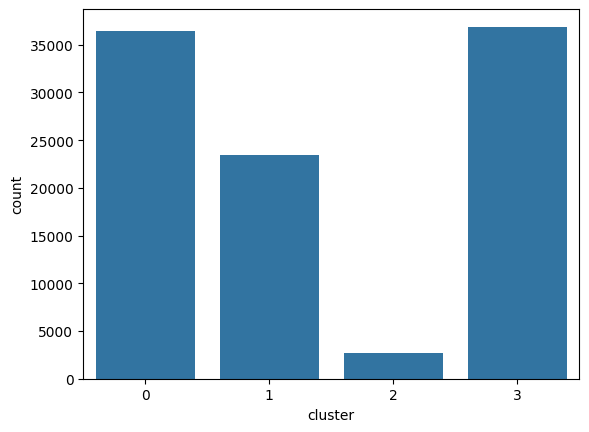

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns. countplot(x='cluster',data=df)
plt.show()

In [12]:
df.to_csv("rfm_segmented.csv", index=False)